In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
from constants import EQ, HH, custom_tech_colors, custom_metal_colors

In [3]:
# Damage files
df_sps_damage = pd.read_excel(r'results/corrected/df_sps_damage_regionalized.xlsx')
df_nze_damage = pd.read_excel(r'results/corrected/df_nze_damage_regionalized.xlsx')
df_ssp2_damage = pd.read_excel(r'results/corrected/df_ssp2_damage_regionalized.xlsx')

In [6]:
df_etm_roe = pd.read_csv(r'results/energy_transition_vs_roe_qty.csv')

In [9]:
# Group into one category for plotting
df_sps_damage["Technology"] = df_sps_damage["Technology"].replace("Other low emissions power generation", "Low emissions power generation")
df_nze_damage["Technology"] = df_nze_damage["Technology"].replace("Other low emissions power generation", "Low emissions power generation")

In [10]:
# Rename
df_sps_damage["Metal"] = df_sps_damage["Metal"].replace("Graphite (battery-grade)", "Graphite")
df_nze_damage["Metal"] = df_nze_damage["Metal"].replace("Graphite (battery-grade)", "Graphite")

In [13]:
# Midpoints file
df_sps_mp = pd.read_csv(r'results/midpoints_results/df_sps_midpoints_regionalized.csv')
df_nze_mp = pd.read_csv(r'results/midpoints_results/df_nze_midpoints_regionalized.csv')

In [14]:
# Additional impact file
df_comparison = pd.read_csv(r'results/comparaison_benefits_burden.csv')

In [15]:
### SET GLOBAL MATPLOTLIB PARAMS
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42  # to Ensure TrueType fonts are embedded
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'arial'
rcParams['font.size'] = 10
rcParams['axes.labelsize'] = 10
rcParams['legend.fontsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['axes.titlesize'] = 12
import seaborn as sns
sns.reset_orig()

# Stacked bar from 2022 to 2050 for metals and technologies

## Metal demand

In [177]:
df_sps_demand = pd.read_csv(r'results/metal_demand/df_sps_metal_demand.csv')
df_nze_demand = pd.read_csv(r'results/metal_demand/df_nze_metal_demand.csv')

In [178]:
# Group into one category for plotting
df_sps_demand["Technology"] = df_sps_demand["Technology"].replace("Other low emissions power generation",
                                                                  "Low emissions power generation")
df_nze_damage["Technology"] = df_nze_damage["Technology"].replace("Other low emissions power generation",
                                                                  "Low emissions power generation")
df_sps_damage["Metal"] = df_sps_damage["Metal"].replace("Graphite (battery-grade)", "Graphite")
df_nze_damage["Metal"] = df_nze_damage["Metal"].replace("Graphite (battery-grade)", "Graphite")

In [179]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, rcParams

def plot_metal_demand_scenarios(df_nze, df_sps, save_path, custom_colors_dict=None):
    """
    Plot 2x2 stacked area charts of metal demand by Technology and Metal
    for NZE and SPS scenarios, with threshold-based grouping for Metal.

    Layout:
    Top row = SPS, Bottom row = NZE
    Left column = Technology, Right column = Metal
    """
    # --- Matplotlib style ---
    rcParams['pdf.fonttype'] = 42
    rcParams['ps.fonttype'] = 42
    rcParams['font.family'] = 'arial'
    rcParams['font.size'] = 10
    rcParams['axes.labelsize'] = 10
    rcParams['legend.fontsize'] = 9
    rcParams['xtick.labelsize'] = 9
    rcParams['ytick.labelsize'] = 9
    rcParams['axes.titlesize'] = 12
    rcParams['text.usetex'] = False
    sns.reset_orig()

    # --- Prepare data ---
    df_nze = df_nze.copy()
    df_sps = df_sps.copy()
    df_nze['Scenario'] = 'NZE'
    df_sps['Scenario'] = 'SPS'
    df_all = pd.concat([df_nze, df_sps], ignore_index=True)

    year_cols = [col for col in df_all.columns if col.isdigit()]
    df_long = df_all.melt(id_vars=['Metal', 'Technology', 'Scenario'], 
                          value_vars=year_cols, var_name='Year', value_name='Demand')
    df_long['Year'] = df_long['Year'].astype(int)

    fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
    plt.subplots_adjust(hspace=0.3, wspace=0.2)

    handles_dict = {'Technology': [], 'Metal': []}
    labels_dict = {'Technology': [], 'Metal': []}

    # Rows: SPS (0), NZE (1); Cols: Technology (0), Metal (1)
    for row_i, scenario in enumerate(['SPS', 'NZE']):
        df_scenario = df_long[df_long['Scenario'] == scenario]
        for col_j, group_by in enumerate(['Technology', 'Metal']):
            ax = axs[row_i, col_j]
            df_grouped = df_scenario.groupby(['Year', group_by])['Demand'].sum().reset_index()

            # Threshold logic for metals
            if group_by == 'Metal':
                total_contrib = df_grouped.groupby(group_by)['Demand'].sum()
                threshold = 0.01
                significant = total_contrib[total_contrib / total_contrib.sum() >= threshold].index
                df_grouped[group_by] = df_grouped[group_by].apply(lambda x: x if x in significant else 'Others')

            df_pivot = df_grouped.pivot_table(index='Year', columns=group_by, values='Demand', aggfunc='sum').fillna(0)
            sorted_cols = df_pivot.loc[df_pivot.index.min()].sort_values(ascending=False).index
            df_pivot = df_pivot[sorted_cols]

            categories = df_pivot.columns.tolist()
            if custom_colors_dict and group_by in custom_colors_dict:
                color_dict = {cat: custom_colors_dict[group_by].get(cat, 'gray') for cat in categories}
                colors = [color_dict[cat] for cat in categories]
            else:
                cmap = cm.get_cmap('tab20', len(categories))
                colors = [cmap(k) for k in range(len(categories))]

            ax.stackplot(df_pivot.index, df_pivot.T, labels=categories, colors=colors, alpha=0.8)
            ax.set_title(f"{scenario} - {group_by}", fontsize=10)
            if row_i == 1:
                ax.set_xlabel("")
            if col_j == 0:
                ax.set_ylabel("kg")

            handles, labels = ax.get_legend_handles_labels()
            handles_dict[group_by] = handles
            labels_dict[group_by] = labels

    # Shared legends
    fig.legend(handles_dict['Technology'], labels_dict['Technology'], 
               loc="lower left", bbox_to_anchor=(0.15, -0.28), fontsize=9)
    fig.legend(handles_dict['Metal'], labels_dict['Metal'], 
               loc="lower right", bbox_to_anchor=(0.85, -0.28), fontsize=9)

    fig.savefig(f"{save_path}.pdf", dpi=600, bbox_inches="tight")
    fig.savefig(f"{save_path}.png", dpi=600, bbox_inches="tight")
    plt.close()



In [180]:
custom_metal_demand = {
    "Copper": "#a50026",
    "Aluminium": "#d73027",
    "Nickel": "#f46d43",
    "Silicon": "#fee090",
    "Graphite": "#e0f3f8",
    "Zinc": "#fee090",
    "Manganese": "#4575b4",
    "Lithium": "#313695",
    "Others": "#A9A9A9", # Generic color for agg categories
}

In [181]:
from constants import custom_metal_colors, custom_tech_colors
custom_colors_dict = {
    "Metal": custom_metal_demand,
    "Technology": custom_tech_colors
}

In [182]:
plot_metal_demand_scenarios(df_nze_demand, df_sps_demand, "results/plots/metal_demand/metal_demand_scenarios", custom_colors_dict)

## LCA impacts

In [15]:
from plotting_functions import plot_combined_stacked_area

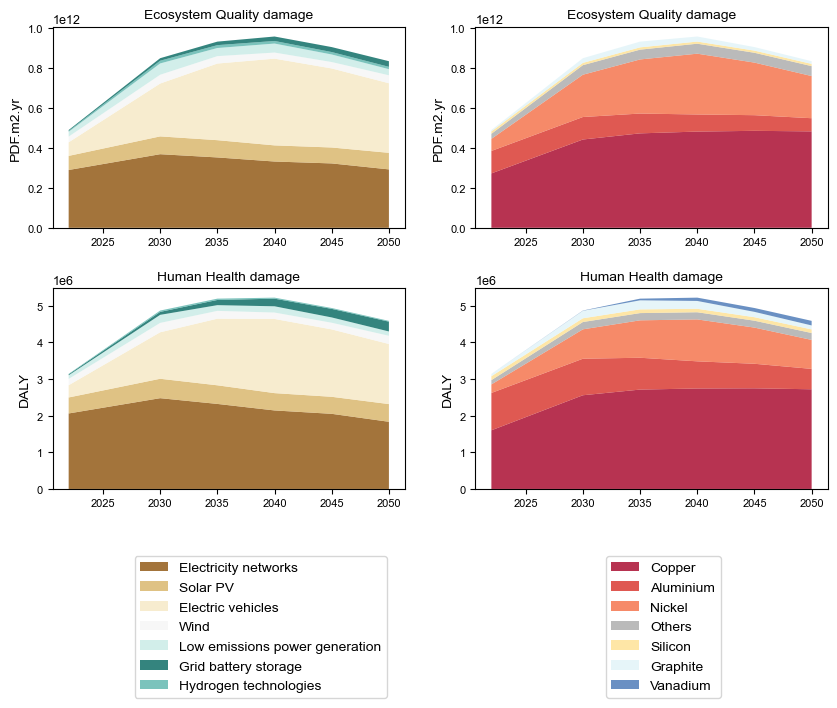

In [16]:
stacked_area_sps = plot_combined_stacked_area(
    df=df_sps_damage,
    value_cols=["Total ecosystem quality", "Total human health"],
    group_by_options=["Technology", "Metal"],
    titles=[
        ["Ecosystem Quality damage", "Ecosystem Quality damage"],
        ["Human Health damage", "Human Health damage"]
    ],
    y_labels=["PDF.m2.yr", "DALY"],
    custom_colors_dict={
        "Technology": custom_tech_colors,
        "Metal": custom_metal_colors
    },
    save_path="results/plots/stacked_area_metals_technologies/combined_stacked_area_sps"
)


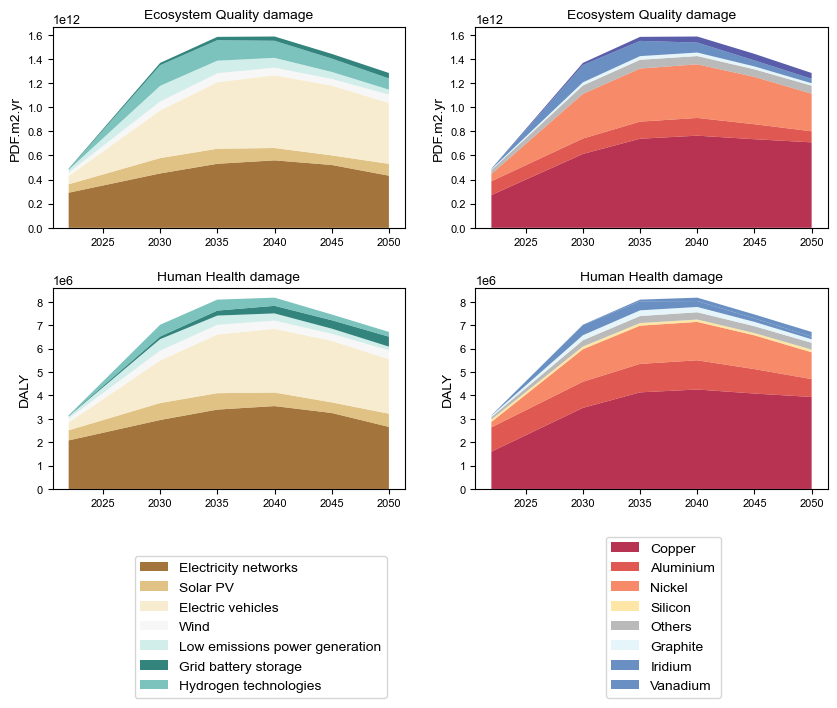

In [17]:
stacked_area_nze = plot_combined_stacked_area(
    df=df_nze_damage,
    value_cols=["Total ecosystem quality", "Total human health"],
    group_by_options=["Technology", "Metal"],
    titles=[
        ["Ecosystem Quality damage", "Ecosystem Quality damage"],
        ["Human Health damage", "Human Health damage"]
    ],
    y_labels=["PDF.m2.yr", "DALY"],
    custom_colors_dict={
        "Technology": custom_tech_colors,
        "Metal": custom_metal_colors
    },
    save_path="results/plots/stacked_area_metals_technologies/combined_stacked_area_nze"
)

# Midpoint contribution analysis

In [ ]:
from constants import agg_mapping_hh, agg_mapping_eq

## Per year

In [ ]:
from plotting_functions import plot_midpoint_contribution

In [90]:
# Define the directory for saving bar plots
barplot_dir = "results/plots/midpoint_contribution"
os.makedirs(barplot_dir, exist_ok=True)

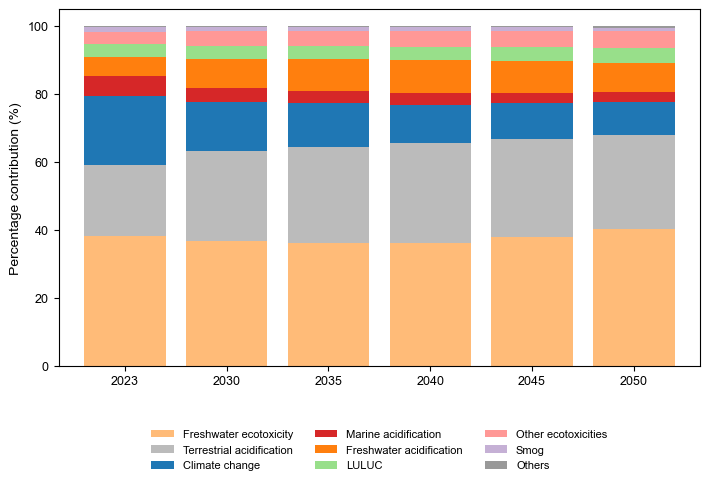

In [91]:
fig_sps_mp_eq = plot_midpoint_contribution(df_sps_damage, 
                                           impact_columns= list(agg_mapping_eq.keys()),
                                           total_col="Total ecosystem quality",
                                           title="Midpoint Contributions to Ecosystem Quality",
                                           mapping_dict=agg_mapping_eq,
                                           save_path=f"{barplot_dir}/fig_sps_mp_eq")

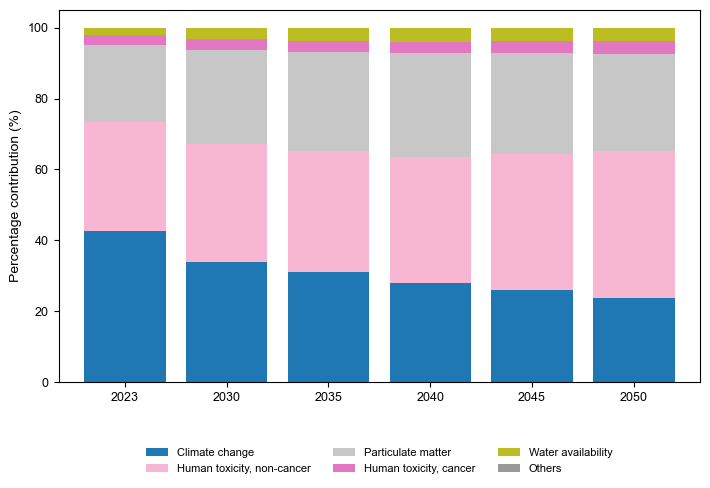

In [92]:
fig_sps_mp_hh = plot_midpoint_contribution(df_sps_damage, 
                                           impact_columns= list(agg_mapping_hh.keys()),
                                           total_col="Total human health",
                                           title="Midpoint Contributions to Human Health",
                                           mapping_dict=agg_mapping_hh,
                                           save_path=f"{barplot_dir}/fig_sps_mp_hh")

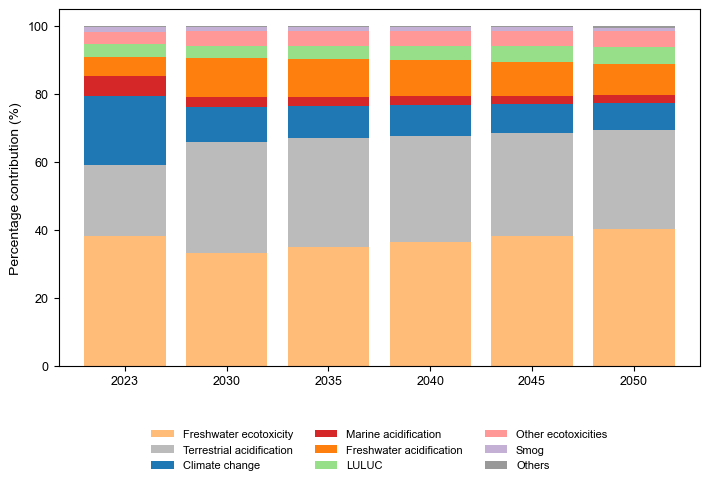

In [93]:
fig_nze_mp_eq = plot_midpoint_contribution(df_nze_damage, 
                                           impact_columns= list(agg_mapping_eq.keys()),
                                           total_col="Total ecosystem quality",
                                           title="Midpoint Contributions to Ecosystem Quality",
                                           mapping_dict=agg_mapping_eq,
                                           save_path=f"{barplot_dir}/fig_nze_mp_eq")

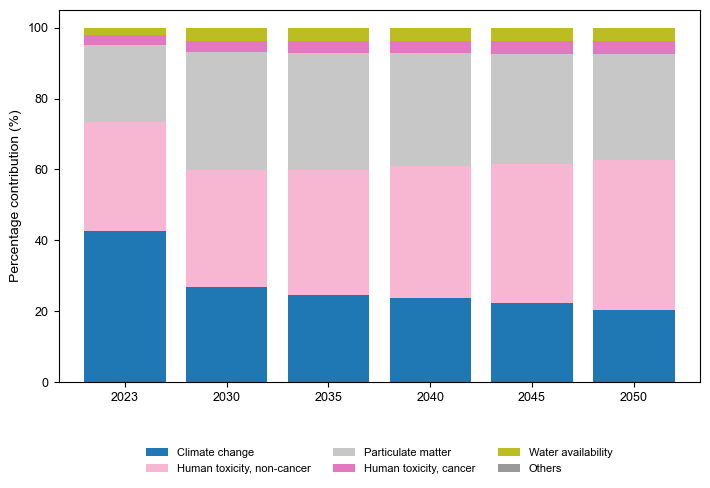

In [94]:
fig_nze_mp_hh = plot_midpoint_contribution(df_nze_damage, 
                                           impact_columns= list(agg_mapping_hh.keys()),
                                           total_col="Total human health",
                                           title="Midpoint Contributions to Human Health",
                                           mapping_dict=agg_mapping_hh,
                                           save_path=f"{barplot_dir}/fig_nze_mp_hh")

## Cumulative

In [34]:
from plotting_functions import plot_cumulative_midpoint_contribution

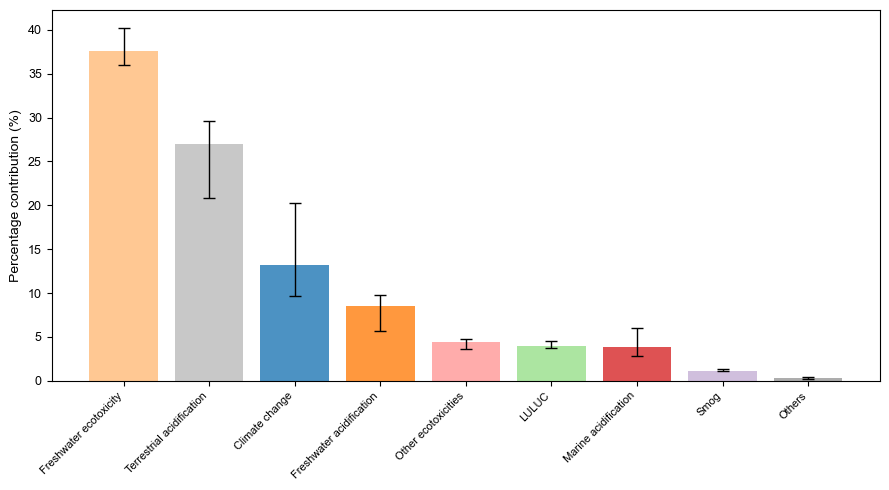

In [98]:
fig_sps_mp_eq_cum = plot_cumulative_midpoint_contribution(df_sps_damage, 
                                                          impact_columns= list(agg_mapping_eq.keys()), 
                                                          total_col="Total ecosystem quality",
                                                          title="Cumulative Midpoint Contributions (2022-2050) - Ecosystem Quality",
                                                          mapping_dict=agg_mapping_eq,
                                                          save_path="results/plots/midpoint_contribution/fig_sps_mp_eq_cum")

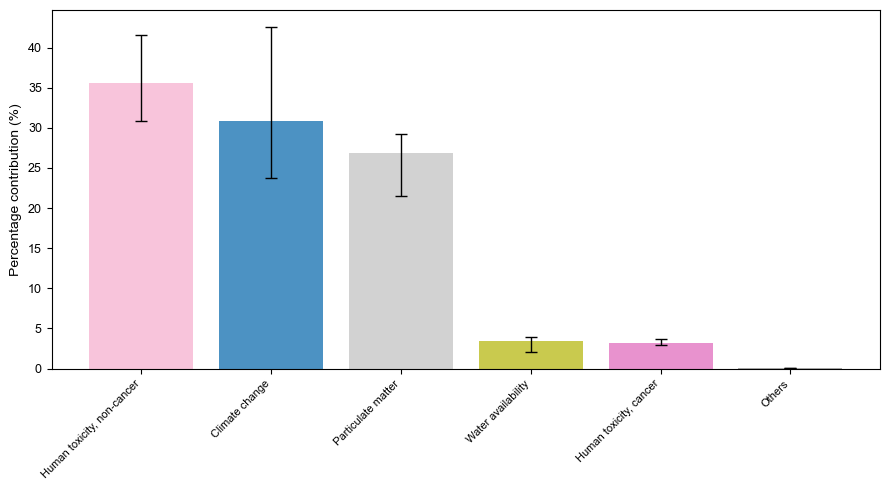

In [99]:
fig_sps_mp_hh_cum = plot_cumulative_midpoint_contribution(df_sps_damage, 
                                                          impact_columns= list(agg_mapping_hh.keys()), 
                                                          total_col="Total human health",
                                                          title="Cumulative Midpoint Contributions (2022-2050) - Human Health",
                                                          mapping_dict=agg_mapping_hh,
                                                          save_path="results/plots/midpoint_contribution/fig_sps_mp_hh_cum")

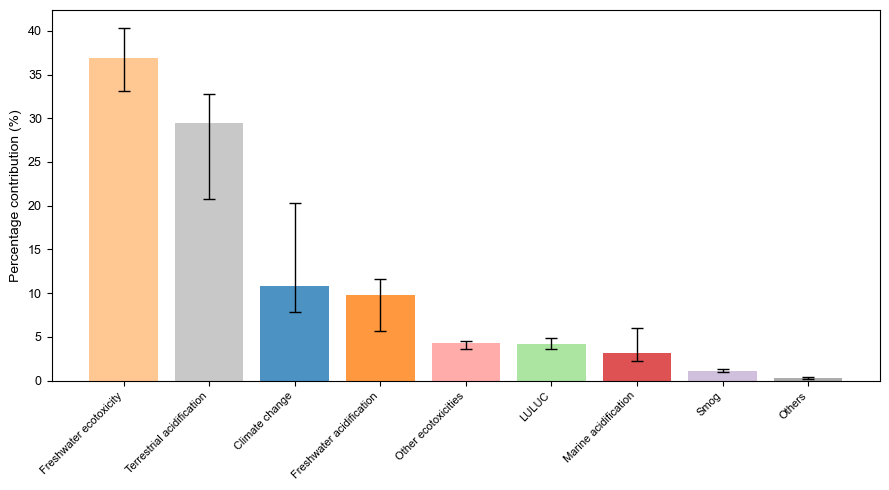

In [100]:
fig_nze_mp_eq_cum = plot_cumulative_midpoint_contribution(df_nze_damage, 
                                                          impact_columns= list(agg_mapping_eq.keys()), 
                                                          total_col="Total ecosystem quality",
                                                          title="Cumulative Midpoint Contributions (2022-2050) - Ecosystem Quality",
                                                          mapping_dict=agg_mapping_eq,
                                                          save_path="results/plots/midpoint_contribution/fig_nze_mp_eq_cum")


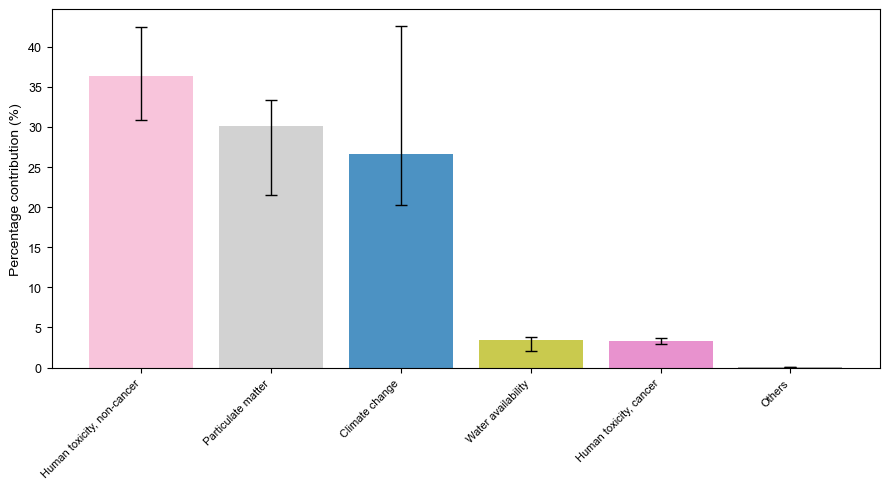

In [101]:
fig_nze_mp_hh_cum = plot_cumulative_midpoint_contribution(df_nze_damage, 
                                                          impact_columns= list(agg_mapping_hh.keys()), 
                                                          total_col="Total human health",
                                                          title="Cumulative Midpoint Contributions (2022-2050) - Human Health",
                                                          mapping_dict=agg_mapping_hh,
                                                          save_path="results/plots/midpoint_contribution/fig_nze_mp_hh_cum")

# Sankey

In [107]:
from plotting_functions import create_sankey

In [108]:
from constants import agg_mapping_eq, agg_mapping_hh, metal_map

In [109]:
# Define directory for saving Sankey diagrams
sankey_dir = "results/plots/sankey"
os.makedirs(sankey_dir, exist_ok=True)

In [61]:
fig_sps_eq = create_sankey(
    df_sps_damage,
    total_col="Total ecosystem quality",
    impact_columns=EQ,
    #title="",
    save_path=f"{sankey_dir}/sps_eq",
    agg_mapping=agg_mapping_eq,
    metal_mapping=metal_map
)

fig_sps_hh = create_sankey(
    df_sps_damage,
    total_col="Total human health",
    impact_columns=HH,
    #title="",
    save_path=f"{sankey_dir}/sps_hh",
    agg_mapping=agg_mapping_hh,
    metal_mapping=metal_map
)


C:\Users\mp_ma\AppData\Local\Temp\ipykernel_21052\4140479495.py:36: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\mp_ma\AppData\Local\Temp\ipykernel_21052\4140479495.py:36: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [110]:
fig_nze_eq = create_sankey(
    df_nze_damage,
    total_col="Total ecosystem quality",
    impact_columns=EQ,
    #title="",
    save_path=f"{sankey_dir}/nze_eq",
    agg_mapping=agg_mapping_eq,
    metal_mapping=metal_map
)

fig_nze_hh = create_sankey(
    df_nze_damage,
    total_col="Total human health",
    impact_columns=HH,
    #title="",
    save_path=f"{sankey_dir}/nze_hh",
    agg_mapping=agg_mapping_hh,
    metal_mapping=metal_map
)

# Benefits vs burden of the transition

In [111]:
from plotting_functions import plot_lineplot_logscale

In [112]:
plot_lineplot_logscale(df_comparison, save_path='results/plots/burden_comparison/lineplot_logscale')

# Energy transition vs rest of the economy

## Subplots

### Quantities

In [113]:
from plotting_functions import plot_all_metals_subplots

In [115]:
plot_all_metals_subplots(
    df_etm_roe,
    ncols=4,
    save_path='results/plots/et_vs_roe/qty_subplots')

### Impacts

In [116]:
from plotting_functions import plot_all_metals_subplots_damage

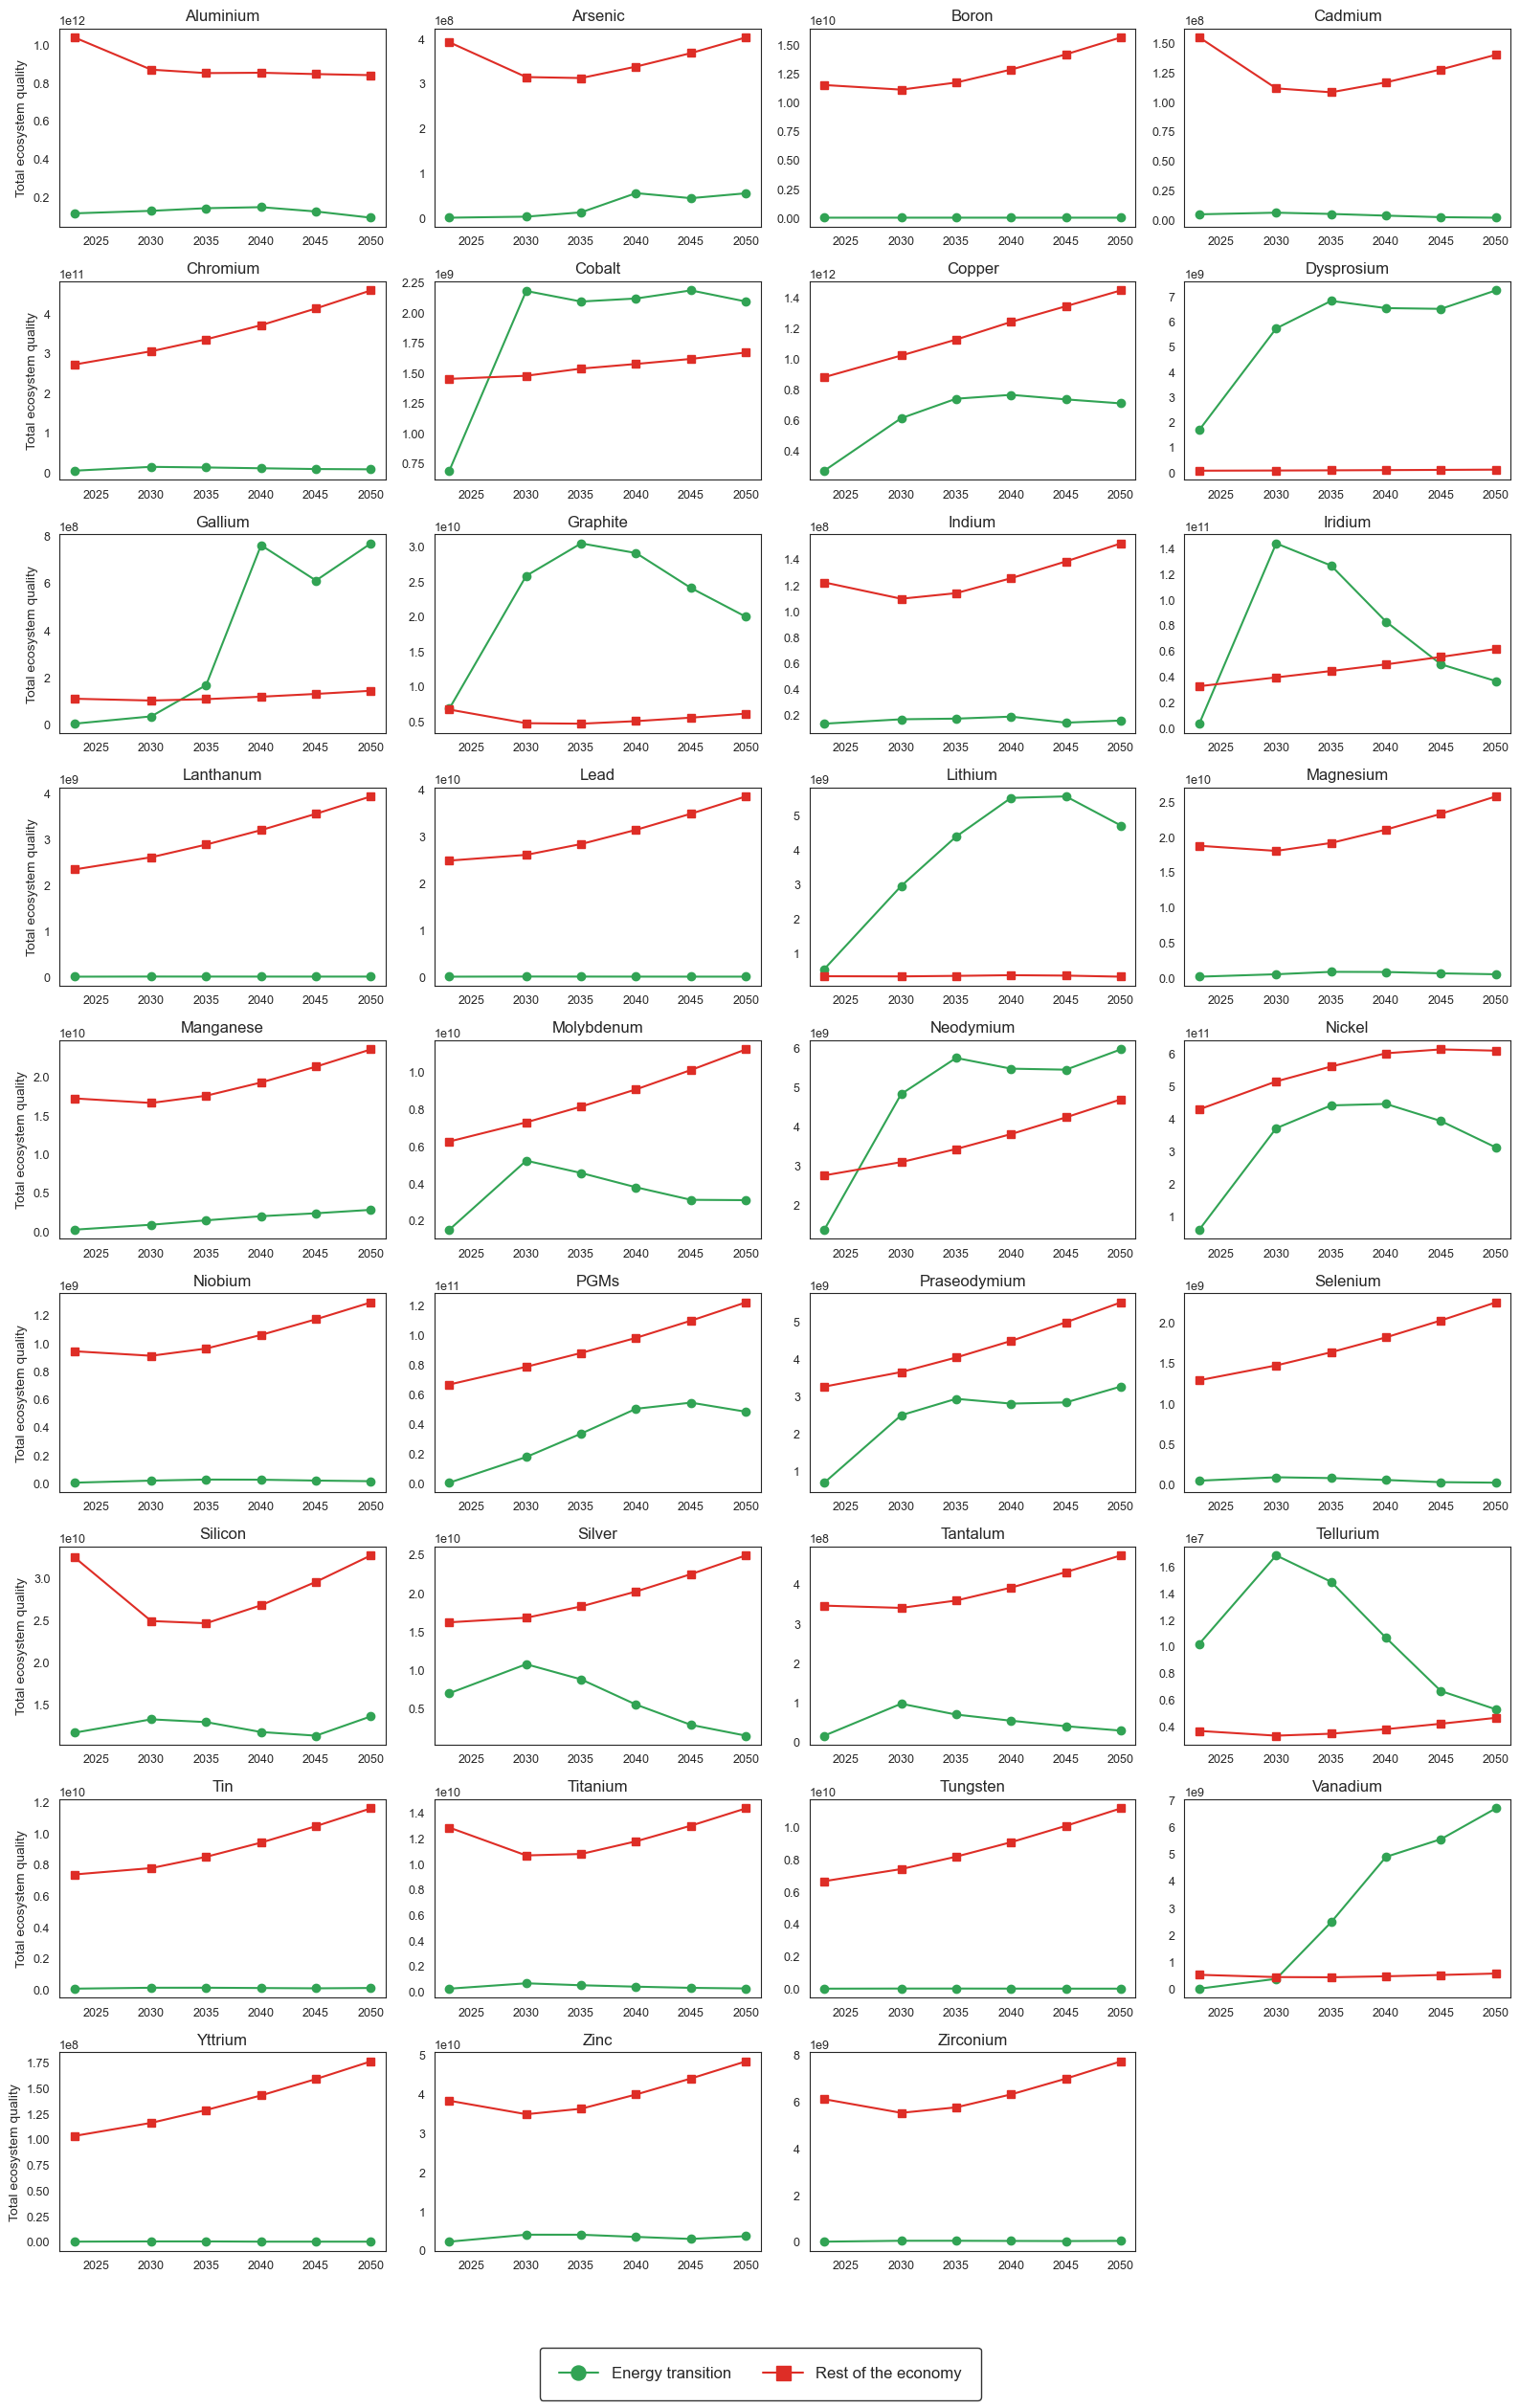

In [117]:
# Re-plot with NZE values aggregated by metal
plot_all_metals_subplots_damage(df_nze_damage, df_ssp2_damage,
                                           impact_type="Total ecosystem quality",
                                           save_path='results/plots/et_vs_roe/eq_subplots',
                                           ncols=4)

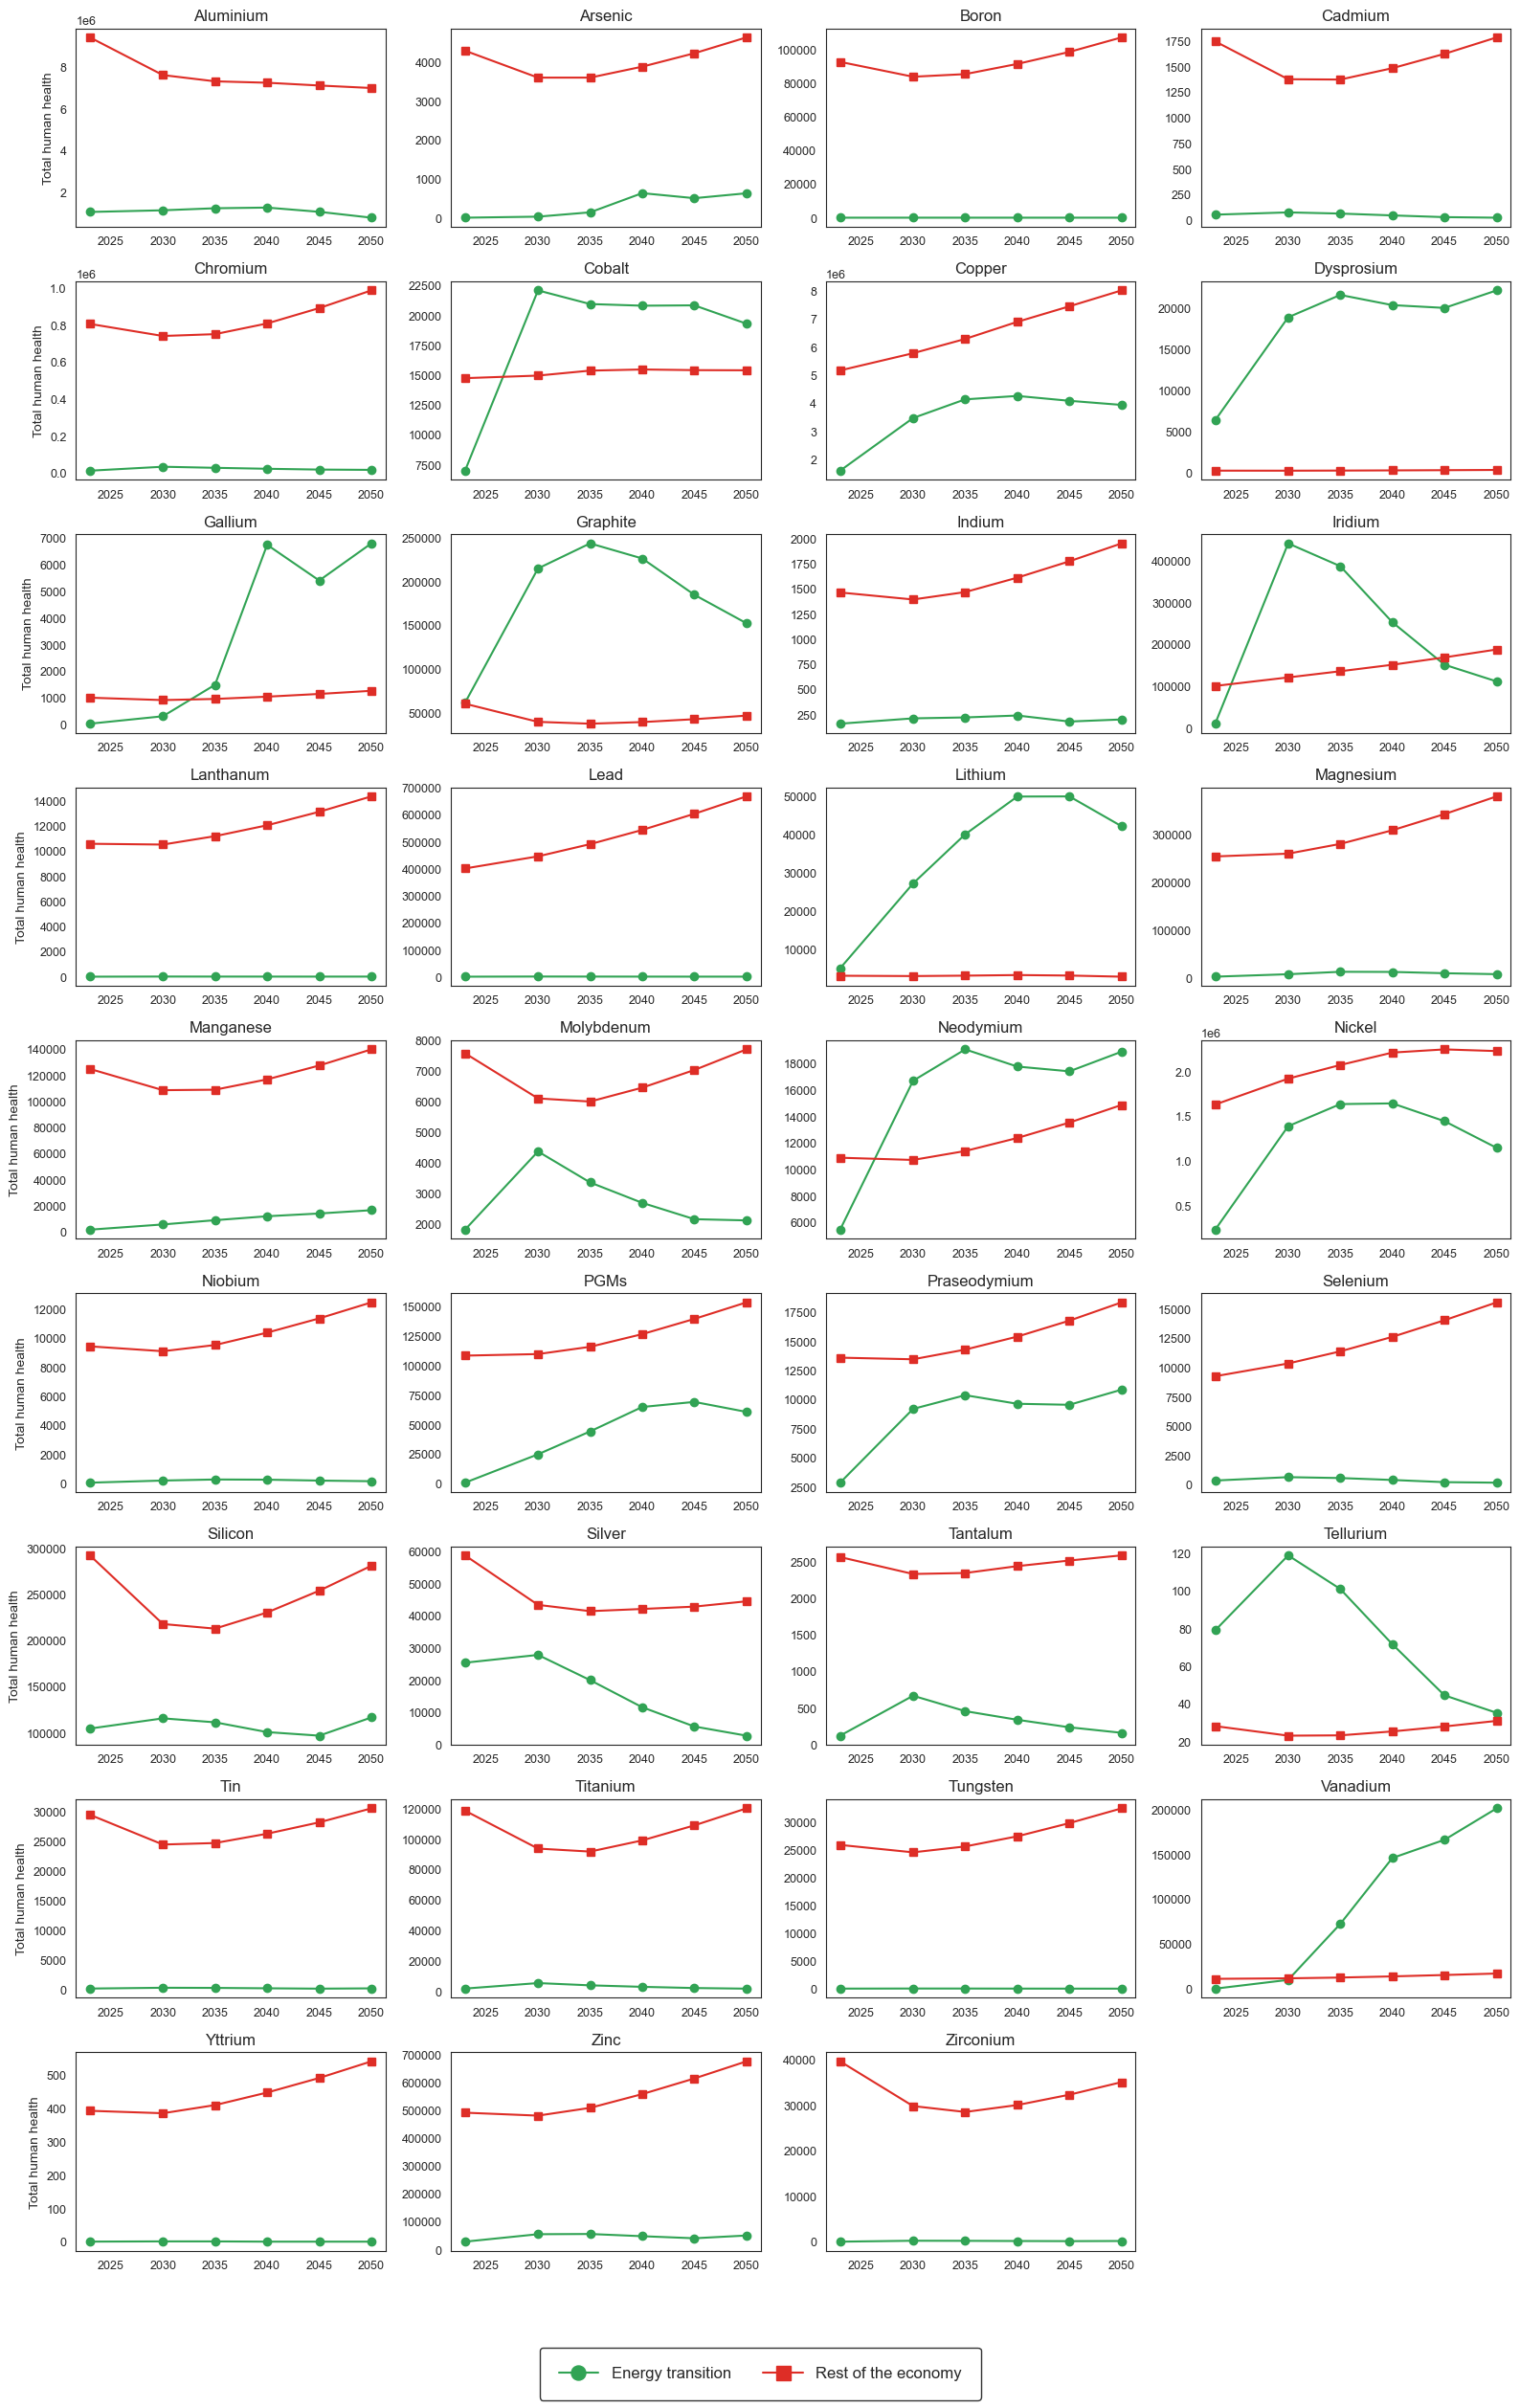

In [118]:
# Re-plot with NZE values aggregated by metal
plot_all_metals_subplots_damage(df_nze_damage, df_ssp2_damage,
                                           impact_type="Total human health",
                                    save_path='results/plots/et_vs_roe/hh_subplots',
                                           ncols=4)

## Stacked area plot

In [124]:
from plotting_functions import plot_stacked_overlay_subplot
from constants import custom_metal_roe_colors

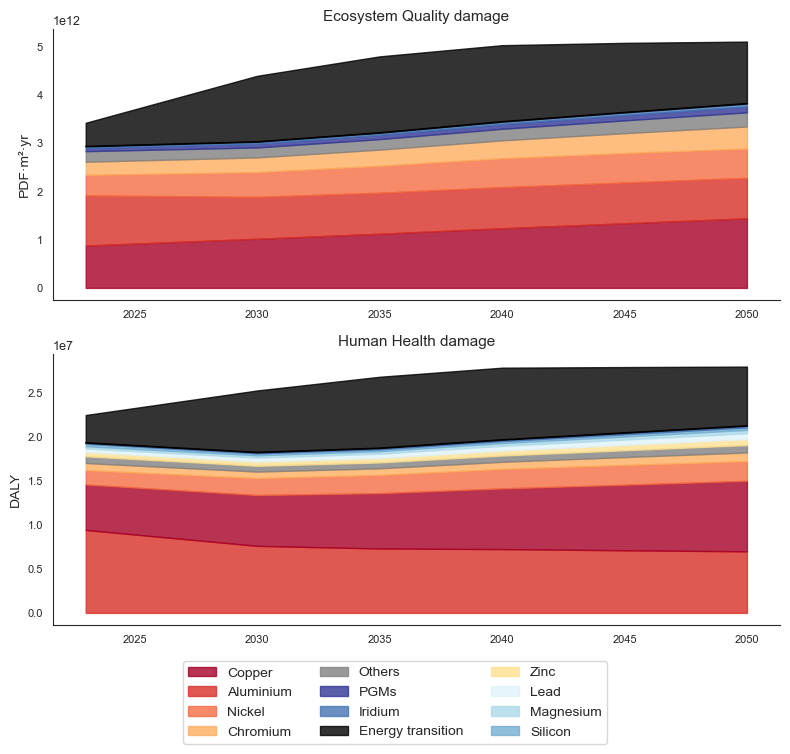

In [125]:
plot_stacked_overlay_subplot(
    df_nze=df_nze_damage,
    df_ssp2=df_ssp2_damage,
    group_by="Metal",
    value_cols=["Total ecosystem quality", "Total human health"],
    titles=["Ecosystem Quality damage", "Human Health damage"],
    y_labels=["PDF·m²·yr", "DALY"],
    custom_colors=custom_metal_roe_colors,
    save_path="results/plots/et_vs_roe/combined_overlay.pdf"
)
